# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: I Made Sandika Wijaya
- Email: sandikakadek2018@gmail.com
- Id Dicoding: I Made Sandika Wijaya

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve

from imblearn.over_sampling import SMOTE
import joblib

### Menyiapkan data yang akan digunakan

In [2]:
employee_df = pd.read_csv(
    "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv",
    encoding='windows-1252'
)
employee_df.head(5)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [3]:
print("Shape:", employee_df.shape)
print("\nInfo:")
print(employee_df.info())

print("\nDescribe:")
print(employee_df.describe())

print("\nMissing Values:")
print(employee_df.isnull().sum())

print("\nDuplicated Rows:")
print(employee_df.duplicated().sum())

print("\nKolom konstan:")
for col in employee_df.columns:
    if employee_df[col].nunique() == 1:
        print(col)

Shape: (1470, 35)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-nul

In [4]:
employee_df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


### Data Cleaning

In [5]:
print("\nShape sebelum cleaning:", employee_df.shape)

# Menghapus baris dengan nilai yang hilang
employee_df.dropna(inplace=True)

# Menghapus kolom konstan dan kolom yang tidak relevan
drop_cols = ['EmployeeId','EmployeeCount','Over18','StandardHours']
employee_df.drop(columns=[col for col in drop_cols if col in employee_df.columns], inplace=True)

print("\nShape setelah cleaning:", employee_df.shape)


Shape sebelum cleaning: (1470, 35)

Shape setelah cleaning: (1058, 31)


## Exploratory Data Analysis

In [6]:
num_df = employee_df.select_dtypes(include='number')
cat_df = employee_df.select_dtypes(exclude='number')

print("Numerical Columns Shape:", num_df.shape)
print("Numerical Columns:", num_df.columns.tolist())

print("\nCategorical Columns Shape:", cat_df.shape)
print("Categorical Columns:", cat_df.columns.tolist())

Numerical Columns Shape: (1058, 24)
Numerical Columns: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns Shape: (1058, 7)
Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


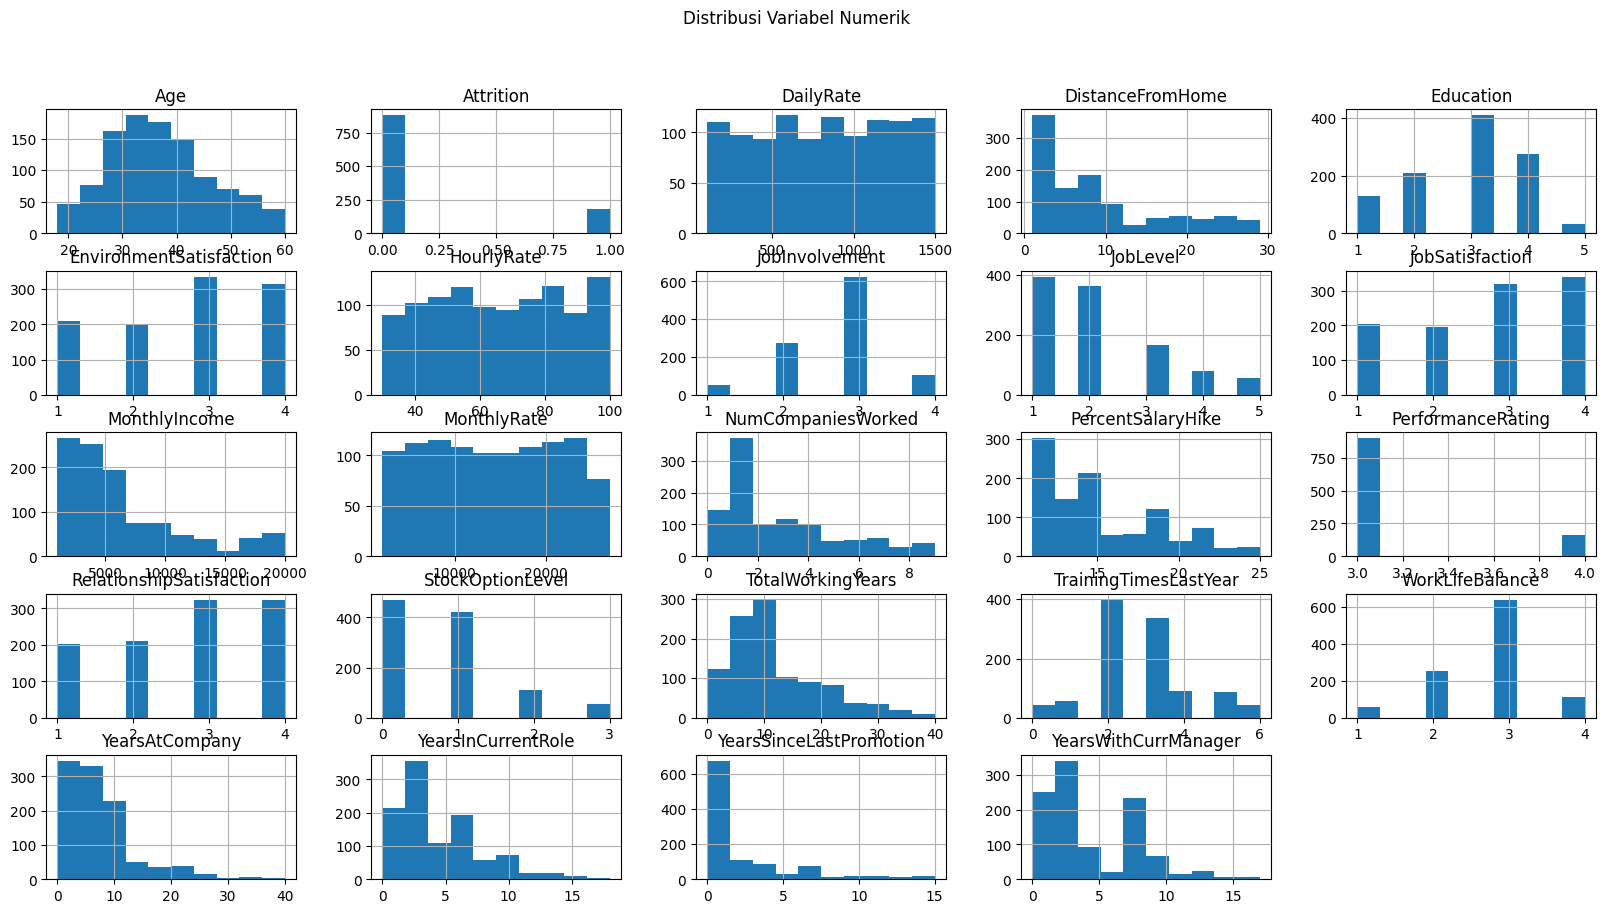

In [7]:
num_df.hist(figsize=(20,10))
plt.suptitle("Distribusi Variabel Numerik")
plt.show()

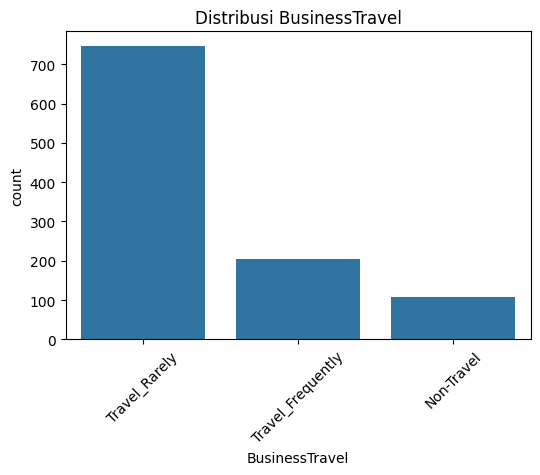

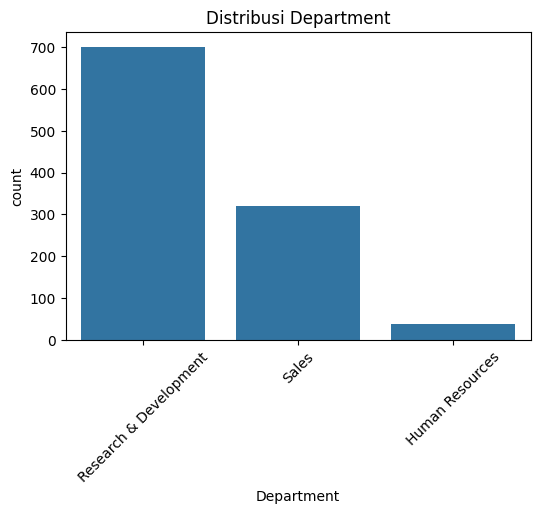

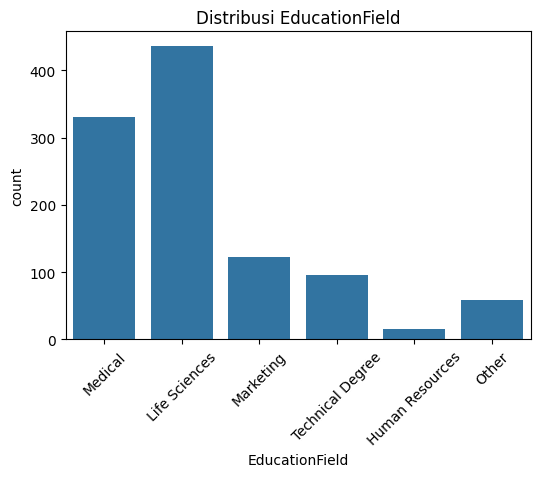

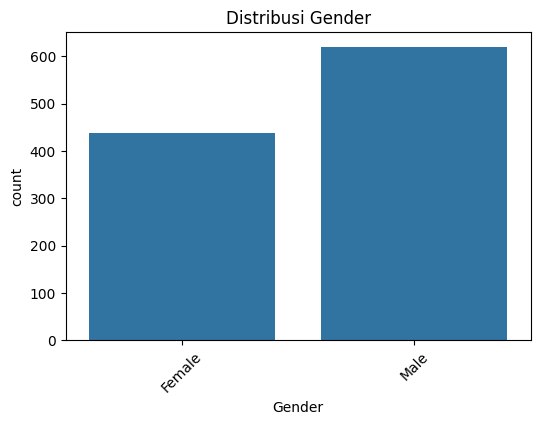

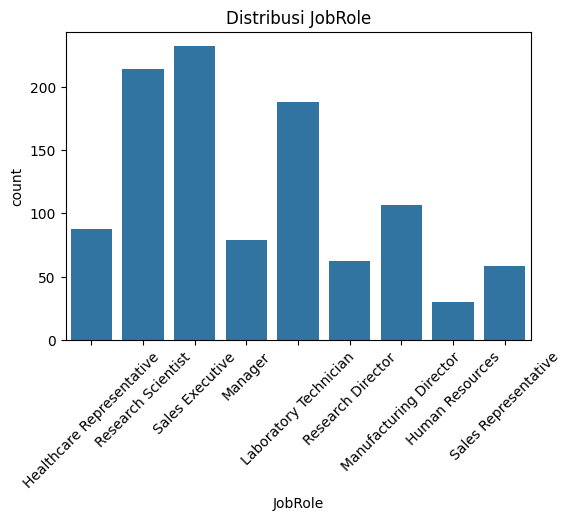

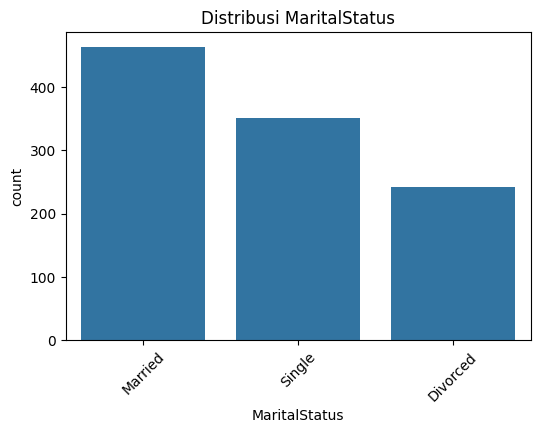

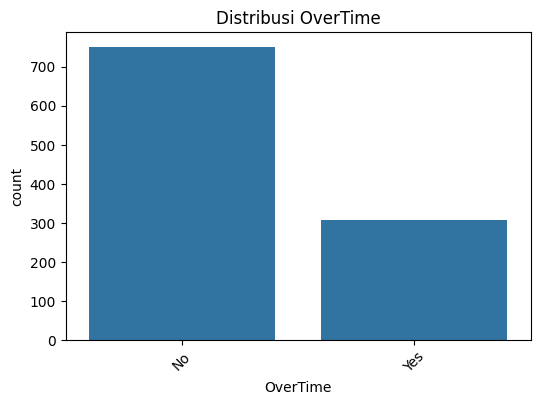

In [8]:
for col in cat_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=employee_df)
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45)
    plt.show()

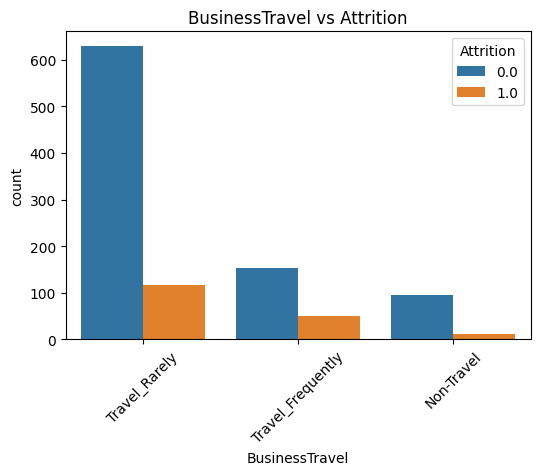

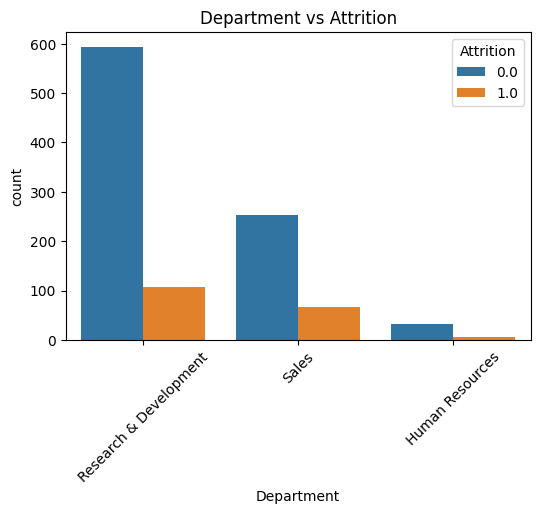

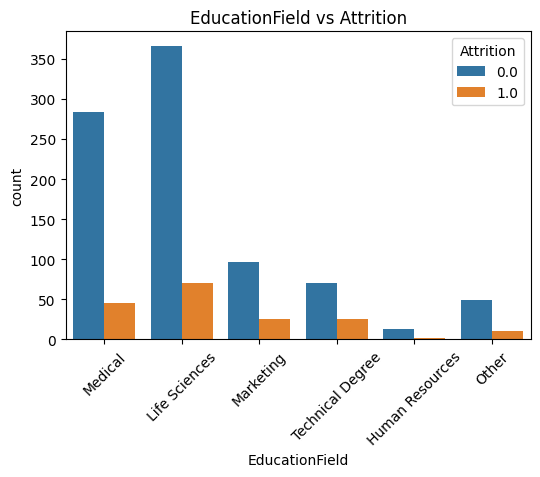

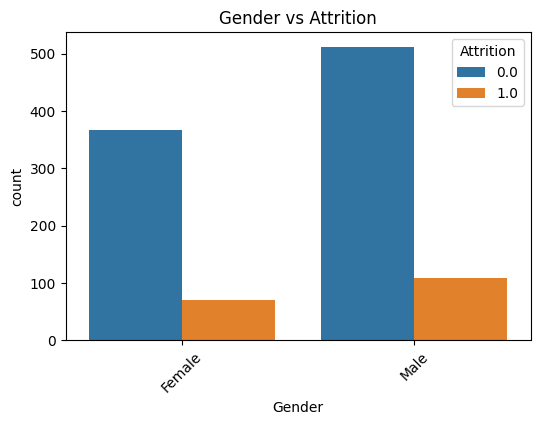

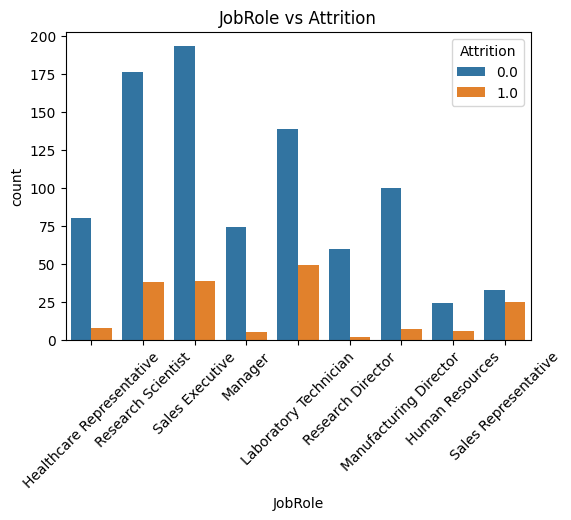

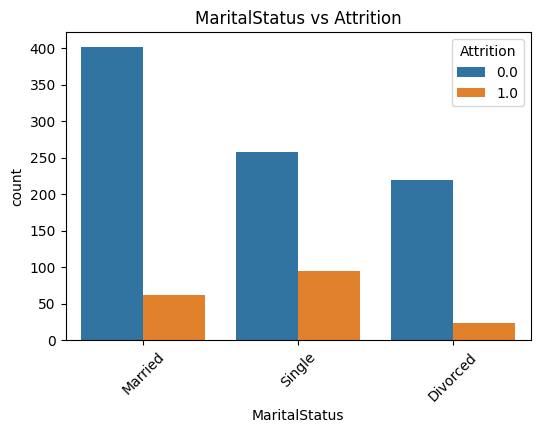

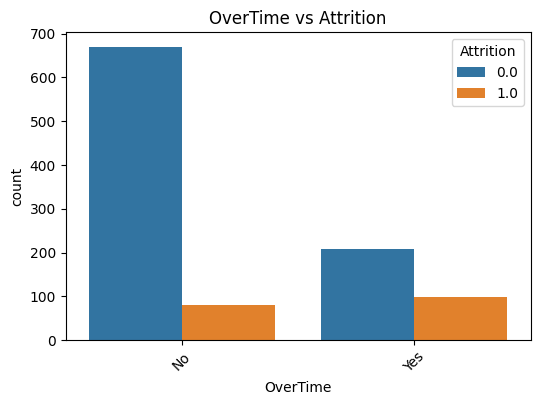

In [9]:
# Categorical vs Target
for col in cat_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Attrition', data=employee_df)
    plt.title(f"{col} vs Attrition")
    plt.xticks(rotation=45)
    plt.show()

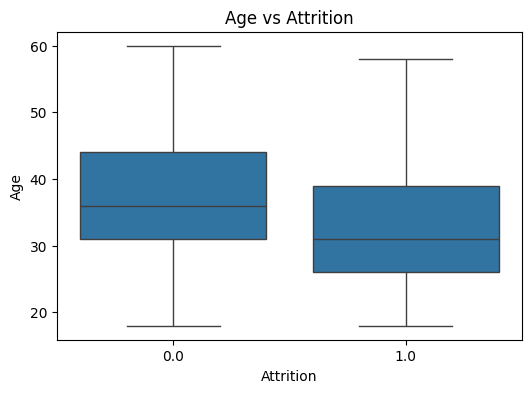

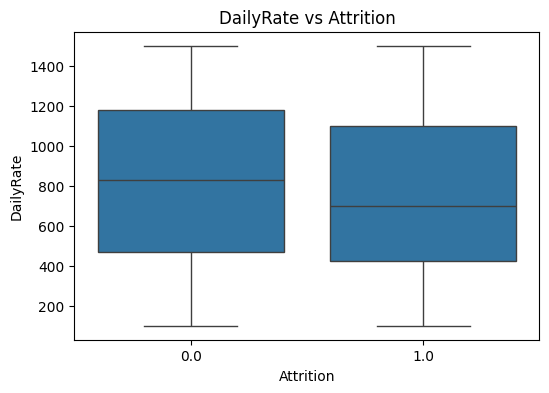

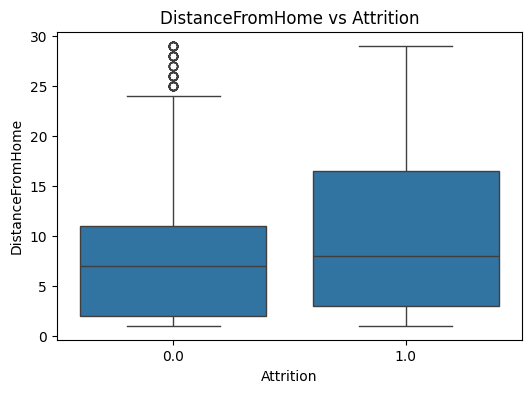

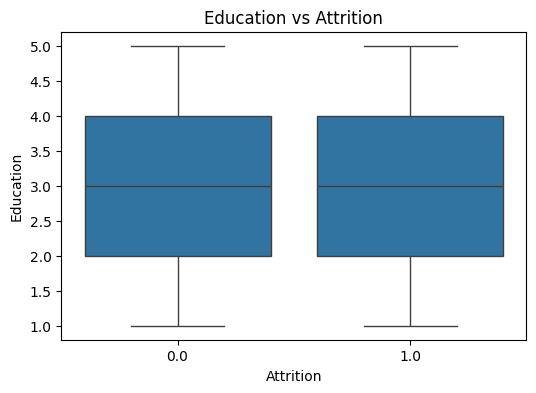

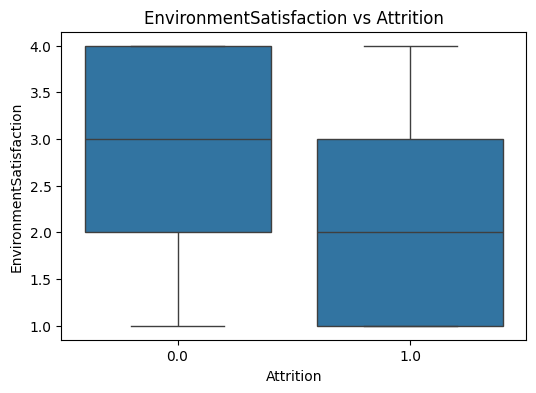

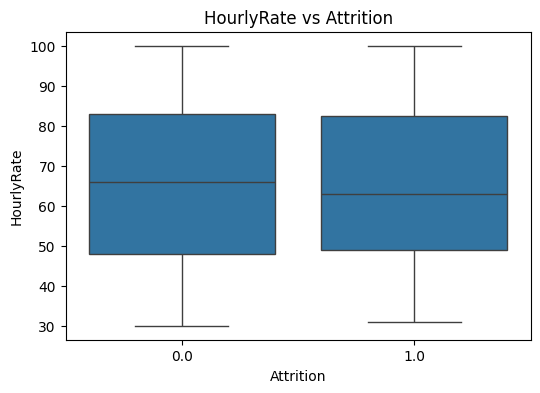

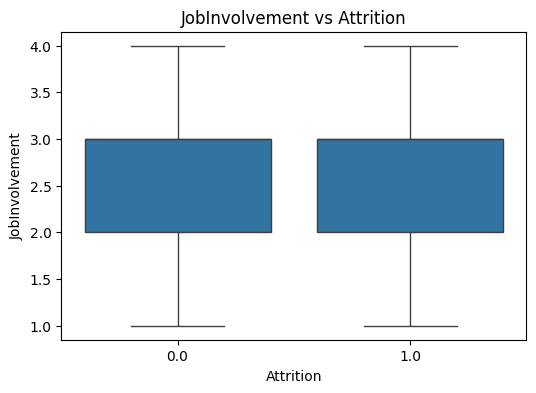

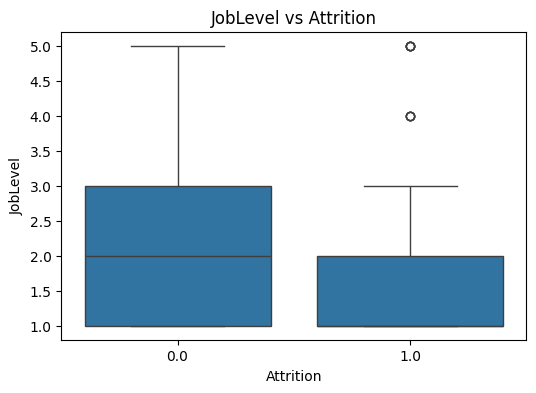

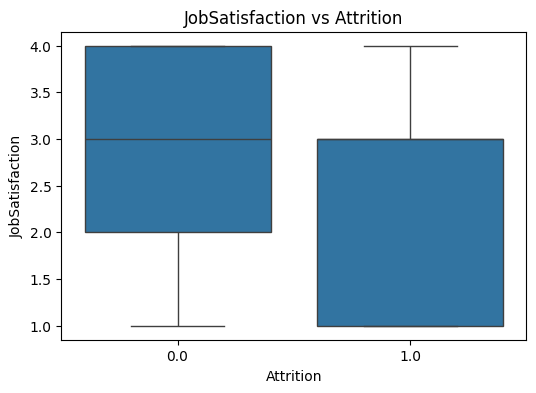

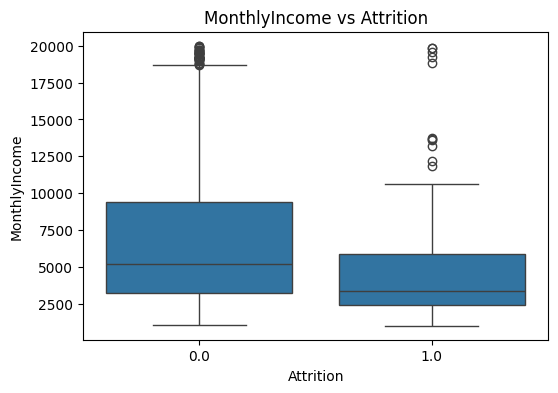

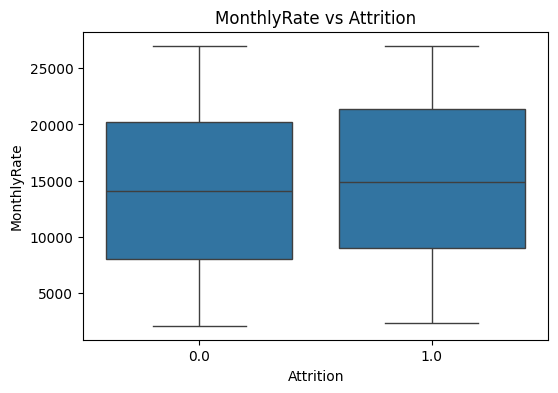

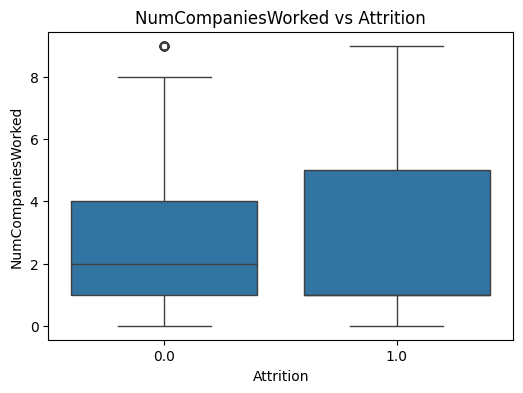

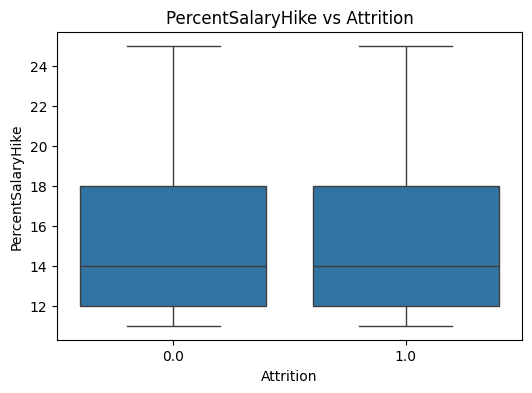

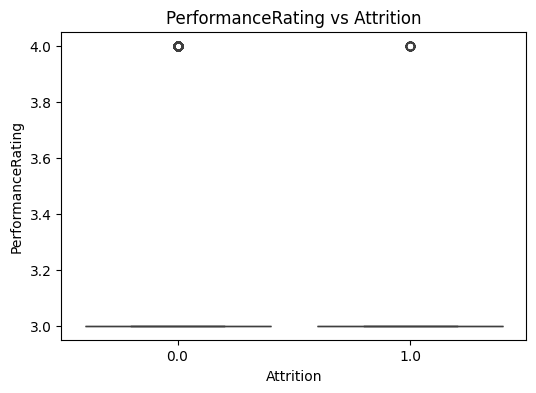

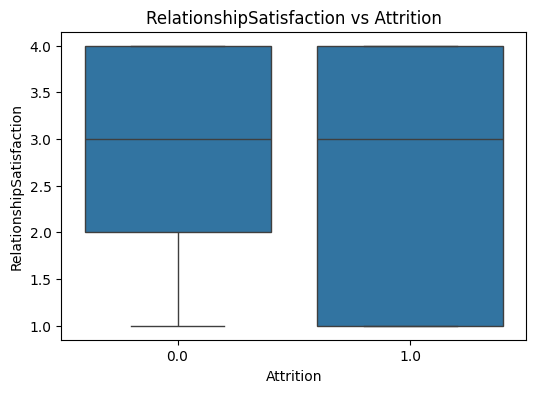

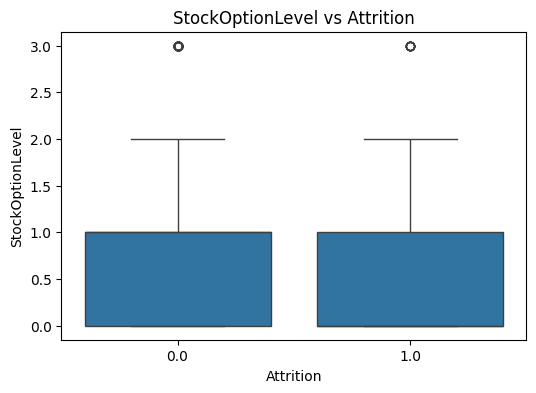

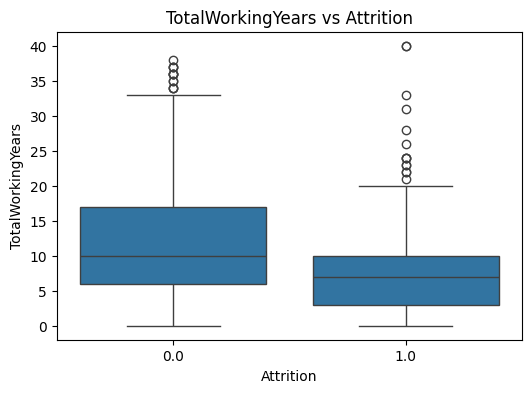

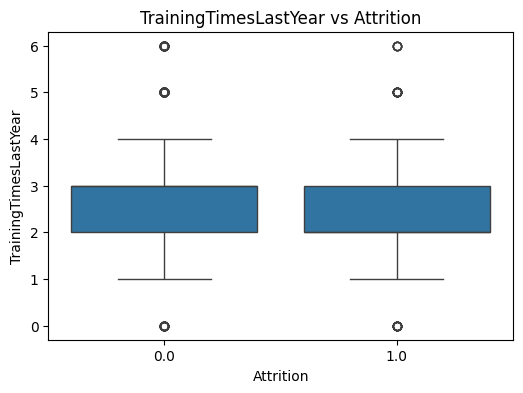

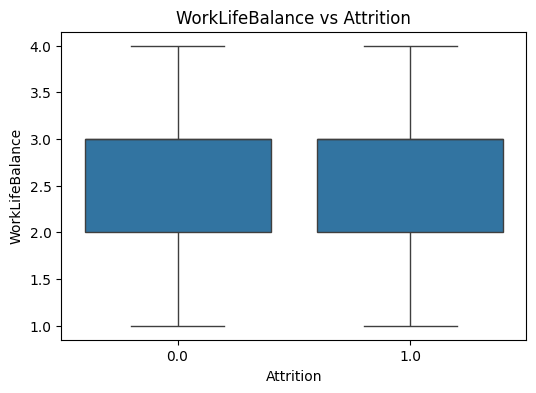

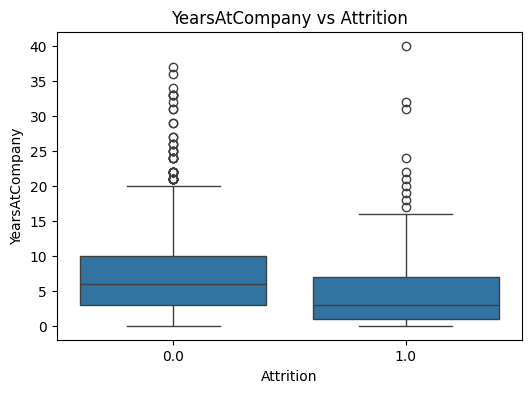

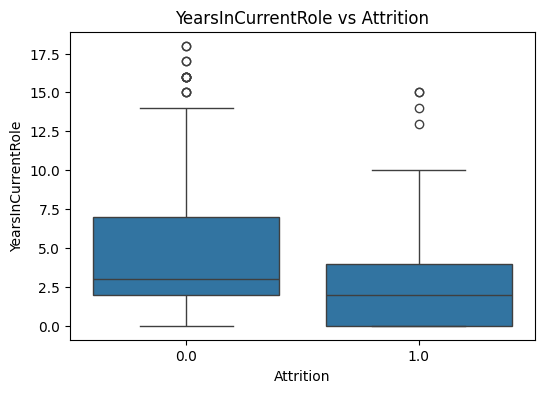

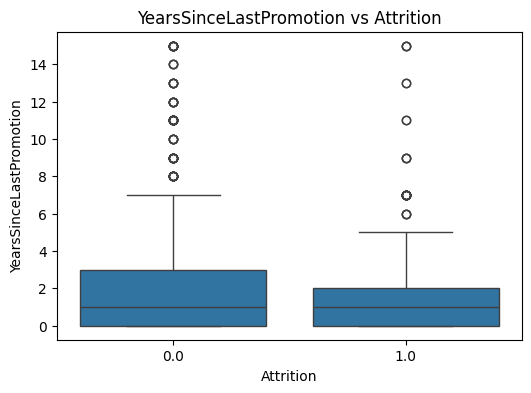

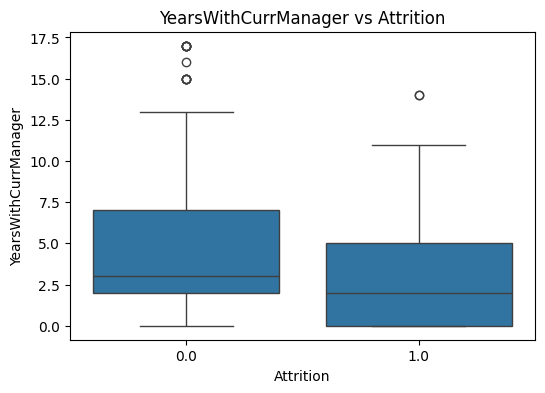

In [10]:
# Numerical vs Target
for col in num_df.columns:
    if col != 'Attrition':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Attrition', y=col, data=employee_df)
        plt.title(f"{col} vs Attrition")
        plt.show()

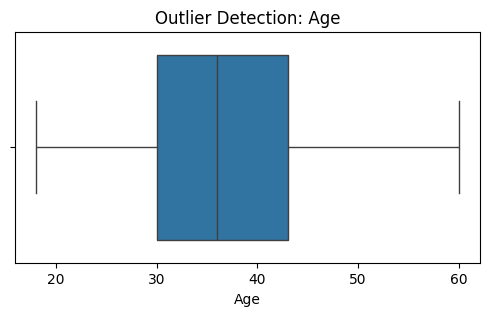

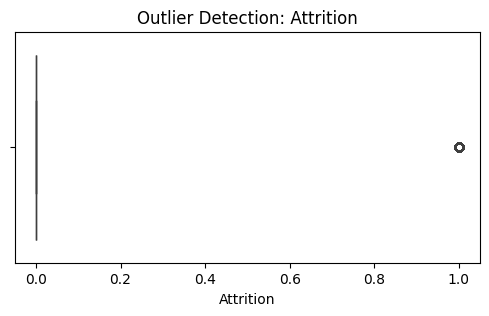

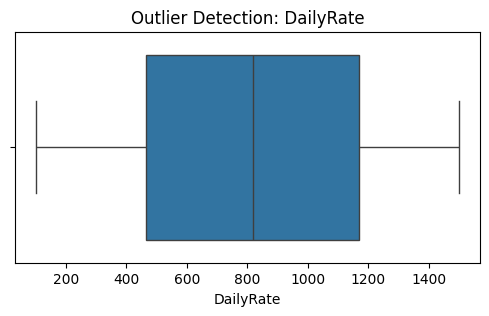

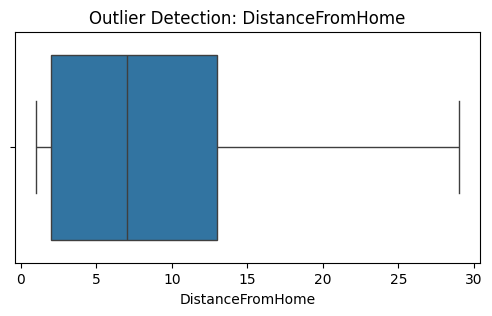

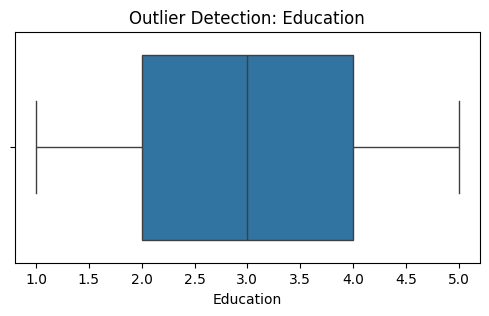

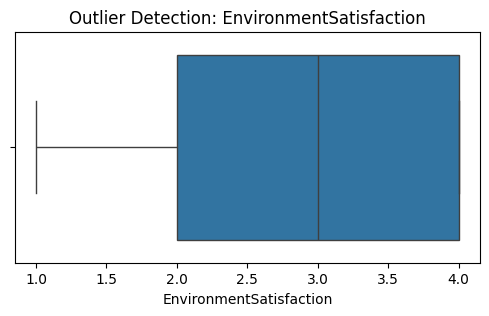

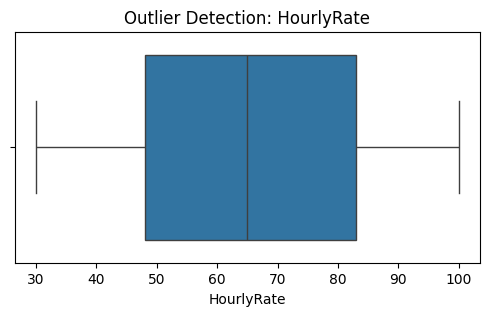

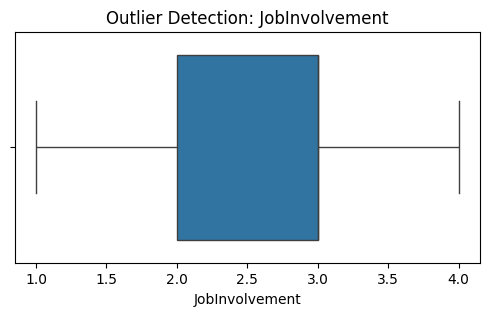

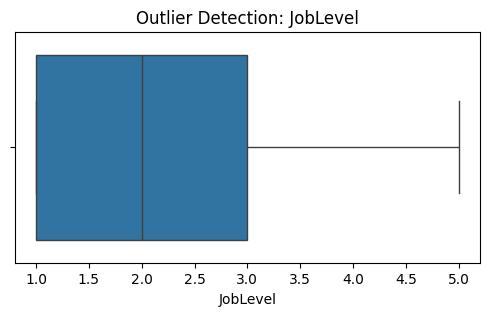

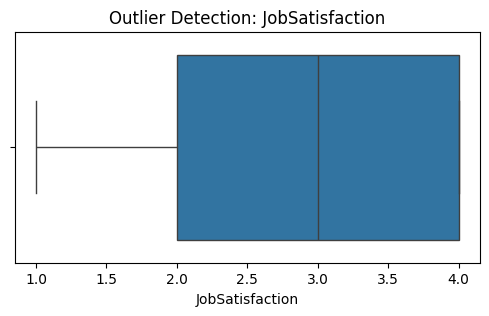

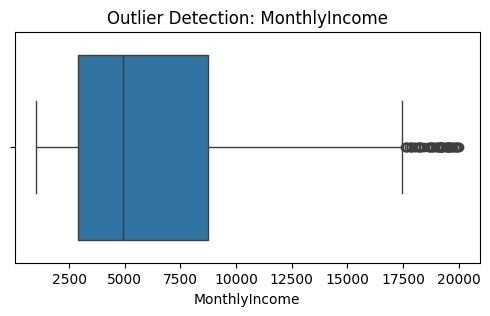

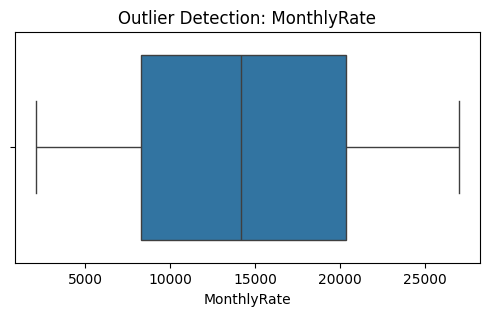

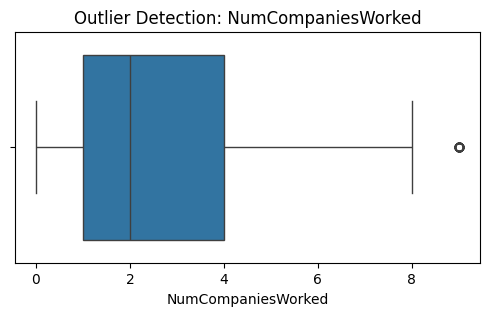

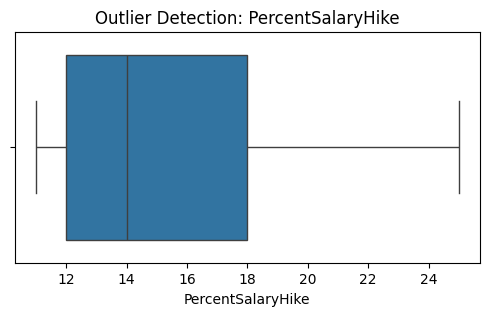

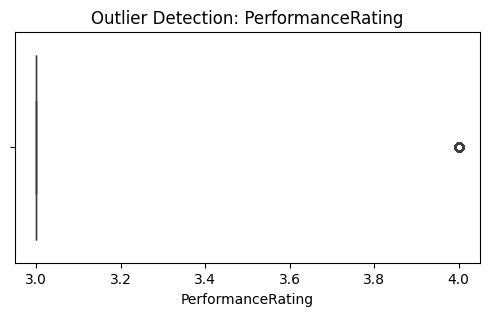

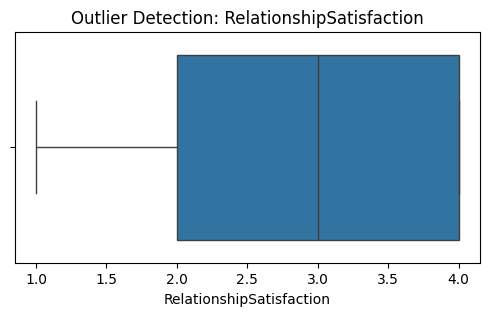

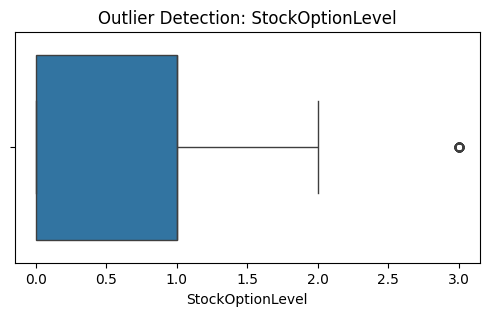

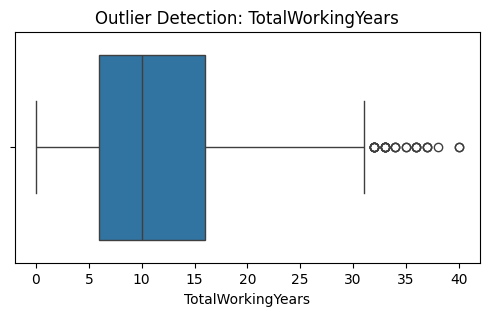

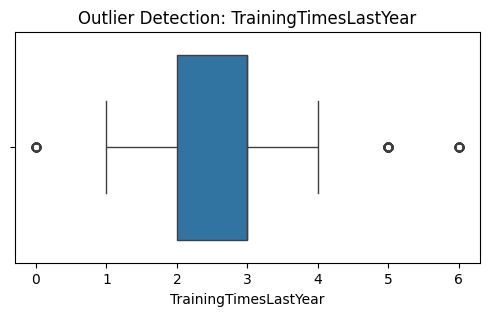

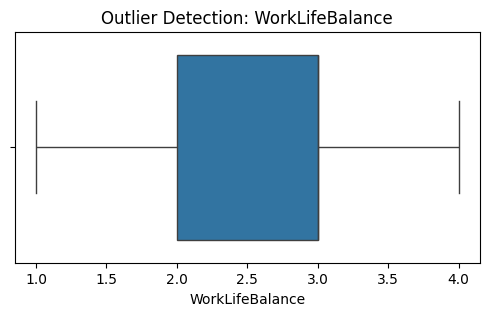

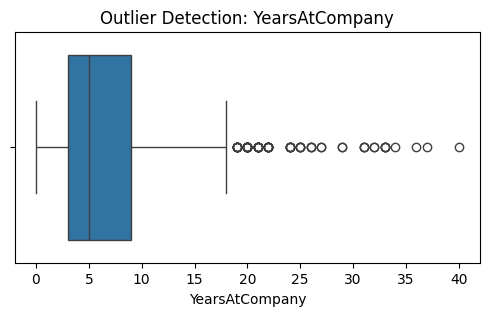

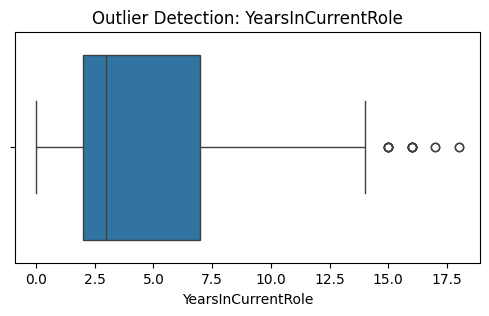

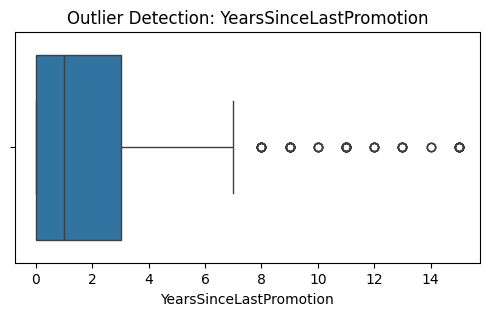

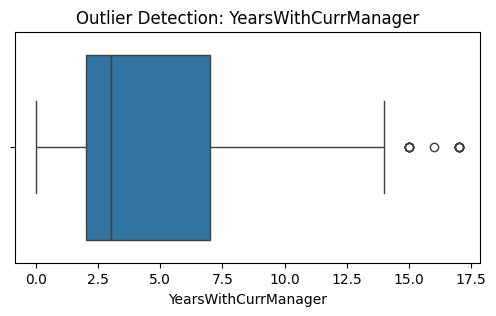

In [11]:
for col in num_df.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=employee_df[col])
    plt.title(f"Outlier Detection: {col}")
    plt.show()

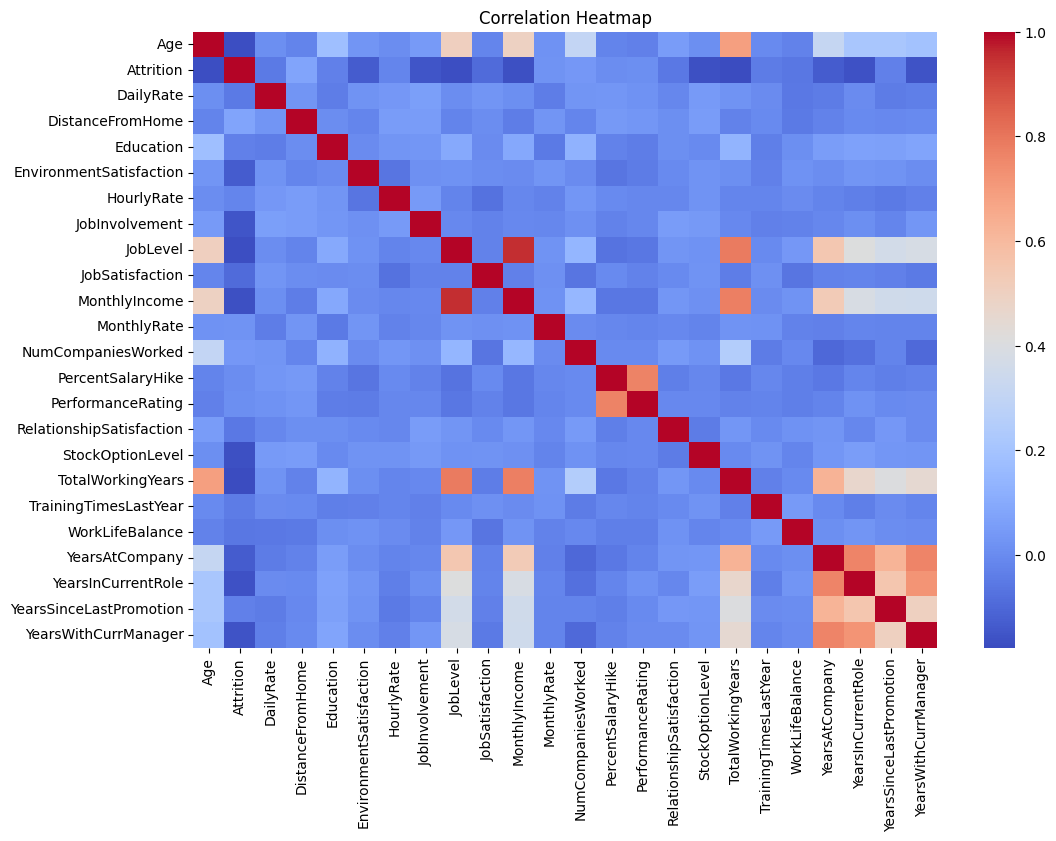

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Distribusi Attrition:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64
Attrition
0.0    0.830813
1.0    0.169187
Name: proportion, dtype: float64


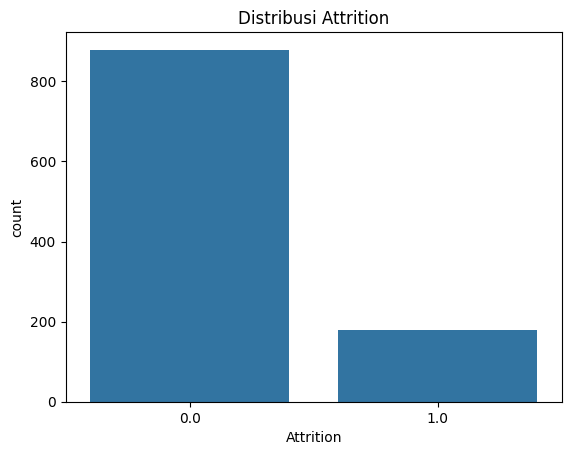

In [13]:
print("\nDistribusi Attrition:")
print(employee_df['Attrition'].value_counts())
print(employee_df['Attrition'].value_counts(normalize=True))

sns.countplot(x='Attrition', data=employee_df)
plt.title("Distribusi Attrition")
plt.show()

## Data Preparation / Preprocessing

In [14]:
le = LabelEncoder()
employee_df['Attrition'] = le.fit_transform(employee_df['Attrition'])

In [16]:
employee_df = pd.get_dummies(employee_df, drop_first=True)

encoded_columns = employee_df.drop("Attrition", axis=1).columns
joblib.dump(encoded_columns, "model/encoded_columns.pkl")

['model/encoded_columns.pkl']

In [17]:
X = employee_df.drop('Attrition', axis=1)
y = employee_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())

Before SMOTE:
Attrition
0    706
1    140
Name: count, dtype: int64

After SMOTE:
Attrition
0    706
1    706
Name: count, dtype: int64


## Modeling

In [20]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_res, y_train_res)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation

In [21]:
# Probabilitas + threshold tuning
y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)

print("=== Base Model ===")
print(classification_report(y_test, y_pred))

=== Base Model ===
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       173
           1       0.56      0.64      0.60        39

    accuracy                           0.84       212
   macro avg       0.74      0.76      0.75       212
weighted avg       0.85      0.84      0.84       212



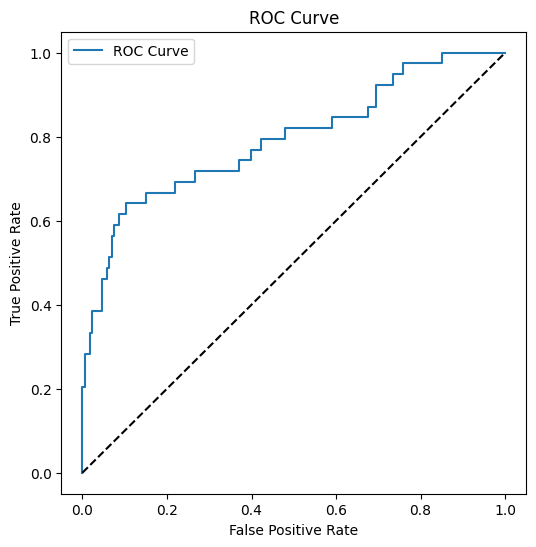

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [23]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top Features:")
print(feat_imp.head(45))

Top Features:
OverTime_Yes                         0.129587
StockOptionLevel                     0.062982
EnvironmentSatisfaction              0.047858
YearsWithCurrManager                 0.046080
MaritalStatus_Single                 0.046038
JobSatisfaction                      0.045975
TotalWorkingYears                    0.044281
YearsAtCompany                       0.034070
Age                                  0.031422
YearsInCurrentRole                   0.031235
MonthlyIncome                        0.030844
DistanceFromHome                     0.028298
JobLevel                             0.027890
HourlyRate                           0.026756
JobInvolvement                       0.026752
MonthlyRate                          0.025408
DailyRate                            0.024655
RelationshipSatisfaction             0.024071
Education                            0.023971
WorkLifeBalance                      0.022843
NumCompaniesWorked                   0.022749
TrainingTimesLastYea

## Save Model

In [24]:
joblib.dump(rf, "model/rf_model_attrition.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']